[*********************100%***********************]  1 of 1 completed

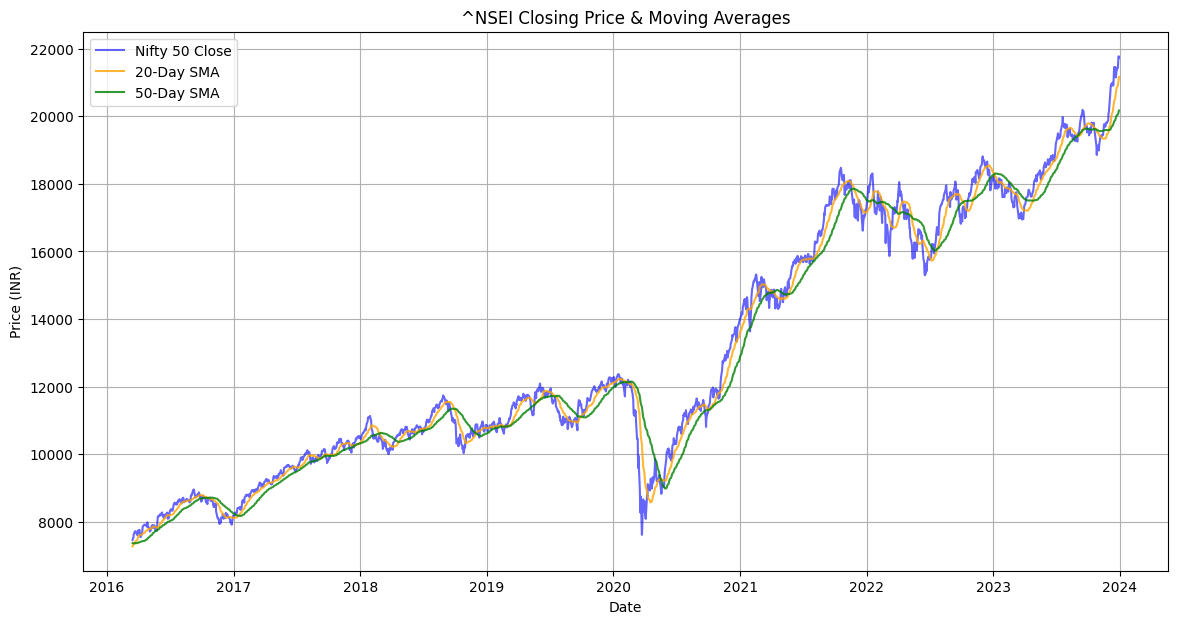

,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False


In [7]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import copy

# ---------------------------------------------------------
# 1. DATA ACQUISITION & FEATURE ENGINEERING (NIFTY 50)
# ---------------------------------------------------------
ticker = "^NSEI"  # Yahoo Finance ticker for Nifty 50
print(f"Downloading historical data for {ticker}...")
df = yf.download(ticker, start="2016-01-01", end="2024-01-01")

# Ensure index is datetime and drop any missing values
df = df.dropna()

# Calculate Technical Indicators
# 1. Moving Averages
df['SMA_20'] = df['Close'].rolling(window=20).mean()
df['SMA_50'] = df['Close'].rolling(window=50).mean()

# 2. MACD (Moving Average Convergence Divergence)
exp1 = df['Close'].ewm(span=12, adjust=False).mean()
exp2 = df['Close'].ewm(span=26, adjust=False).mean()
df['MACD'] = exp1 - exp2
df['Signal_Line'] = df['MACD'].ewm(span=9, adjust=False).mean()

# 3. RSI (Relative Strength Index)
delta = df['Close'].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / loss
df['RSI'] = 100 - (100 / (1 + rs))

# Drop NaN values generated by rolling windows
df = df.dropna()

# Exploratory Data Analysis (EDA) Plot
plt.figure(figsize=(14, 7))
plt.plot(df.index, df['Close'], label='Nifty 50 Close', color='blue', alpha=0.6)
plt.plot(df.index, df['SMA_20'], label='20-Day SMA', color='orange', alpha=0.8)
plt.plot(df.index, df['SMA_50'], label='50-Day SMA', color='green', alpha=0.8)
plt.title(f"{ticker} Closing Price & Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price (INR)")
plt.legend()
plt.grid(True)
plt.show()

# Define features to use (Removed 'Volume' to prevent Index data issues)
features = ['Close', 'SMA_20', 'SMA_50', 'MACD', 'Signal_Line', 'RSI']
data = df[features].values

# ---------------------------------------------------------
# SCALING
# ---------------------------------------------------------
feature_scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = feature_scaler.fit_transform(data)

# Dedicated scaler JUST for the target ('Close' price)
target_scaler = MinMaxScaler(feature_range=(0, 1))
target_scaler.fit(df[['Close']])

In [8]:
# ---------------------------------------------------------
# 2. SEQUENCE GENERATION & DATALOADERS
# ---------------------------------------------------------
def create_sequences(data, lookback):
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i-lookback:i, :]) # All features for the past 'lookback' days
        y.append(data[i, 0])            # The 'Close' price (index 0) of the current day
    return np.array(X), np.array(y)

lookback_window = 60
X, y = create_sequences(scaled_data, lookback_window)

# Chronological Train/Test Split (80/20)
split_index = int(len(X) * 0.8)

X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

# Convert to PyTorch Tensors
# X shape: (Batch, Sequence, Features), y shape: (Batch, 1)
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

# Create PyTorch Datasets and DataLoaders
from torch.utils.data import TensorDataset, DataLoader

batch_size = 32

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# SHUFFLE MUST BE FALSE for time-series predictability mapping
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Training data shape: {X_train_tensor.shape}")
print(f"Testing data shape: {X_test_tensor.shape}")

Training data shape: torch.Size([1488, 60, 6])
Testing data shape: torch.Size([372, 60, 6])


In [9]:
# ---------------------------------------------------------
# 3. LSTM ARCHITECTURE
# ---------------------------------------------------------
class StockLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size, dropout_rate=0.2):
        super(StockLSTM, self).__init__()
        
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        # batch_first=True ensures input tensor is expected as (batch, seq, feature)
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, 
                            batch_first=True, dropout=dropout_rate if num_layers > 1 else 0)
        
        # Dropout layer to prevent overfitting
        self.dropout = nn.Dropout(dropout_rate)
        
        # Fully connected layer mapping hidden state to output (1 value: predicted price)
        self.fc = nn.Linear(hidden_size, output_size)
        
    def forward(self, x):
        # Initialize hidden and cell states with zeros
        # h0/c0 shape: (num_layers, batch_size, hidden_size)
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        
        # Forward propagate LSTM
        # out shape: (batch_size, seq_length, hidden_size)
        # We also get the final hidden and cell states (hn, cn), which we don't strictly need here
        out, _ = self.lstm(x, (h0, c0))
        
        # Extract the hidden state from the LAST time step of the sequence
        # out[:, -1, :] slices the tensor to get all batches, the final sequence step, and all hidden features
        last_time_step_out = out[:, -1, :]
        
        # Pass through dropout and linear layer
        out = self.dropout(last_time_step_out)
        out = self.fc(out)
        
        return out

# Instantiate model
input_size = len(features) # Number of features (7)
hidden_size = 64
num_layers = 2
output_size = 1

model = StockLSTM(input_size, hidden_size, num_layers, output_size)

In [10]:
# ---------------------------------------------------------
# 4. TRAINING LOOP & EARLY STOPPING
# ---------------------------------------------------------
# Device agnostic setup (CUDA for Nvidia, MPS for Apple Silicon, else CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Training on device: {device}")

model = model.to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

num_epochs = 100
patience = 10
best_val_loss = float('inf')
patience_counter = 0
best_model_weights = None

train_losses = []
val_losses = []

for epoch in range(num_epochs):
    # --- TRAINING STAGE ---
    model.train()
    running_train_loss = 0.0
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        
        # 1. Zero gradients
        optimizer.zero_grad()
        
        # 2. Forward pass
        outputs = model(batch_X)
        
        # 3. Calculate loss
        loss = criterion(outputs, batch_y)
        
        # 4. Backward pass & optimize
        loss.backward()
        optimizer.step()
        
        running_train_loss += loss.item() * batch_X.size(0)
        
    epoch_train_loss = running_train_loss / len(train_loader.dataset)
    train_losses.append(epoch_train_loss)
    
    # --- VALIDATION STAGE ---
    model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for batch_X, batch_y in test_loader: # using test set as validation here
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            running_val_loss += loss.item() * batch_X.size(0)
            
    epoch_val_loss = running_val_loss / len(test_loader.dataset)
    val_losses.append(epoch_val_loss)
    
    print(f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {epoch_train_loss:.6f} | Val Loss: {epoch_val_loss:.6f}")
    
    # --- EARLY STOPPING LOGIC ---
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        patience_counter = 0
        # Save best weights in memory (could also use torch.save to disk)
        best_model_weights = copy.deepcopy(model.state_dict())
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}.")
            break

# Load the best model weights
model.load_state_dict(best_model_weights)
torch.save(model.state_dict(), 'best_stock_lstm.pth')
print("Best model saved.")

Training on device: cuda
Epoch [1/100] | Train Loss: 0.016183 | Val Loss: 0.006567
Epoch [2/100] | Train Loss: 0.068107 | Val Loss: 0.116069
Epoch [3/100] | Train Loss: 0.043678 | Val Loss: 0.081049
Epoch [4/100] | Train Loss: 0.028699 | Val Loss: 0.008468
Epoch [5/100] | Train Loss: 0.014486 | Val Loss: 0.014412
Epoch [6/100] | Train Loss: 0.006081 | Val Loss: 0.001365
Epoch [7/100] | Train Loss: 0.005766 | Val Loss: 0.001834
Epoch [8/100] | Train Loss: 0.004109 | Val Loss: 0.002676
Epoch [9/100] | Train Loss: 0.001846 | Val Loss: 0.002013
Epoch [10/100] | Train Loss: 0.001786 | Val Loss: 0.002190
Epoch [11/100] | Train Loss: 0.001637 | Val Loss: 0.003244
Epoch [12/100] | Train Loss: 0.001785 | Val Loss: 0.001973
Epoch [13/100] | Train Loss: 0.001806 | Val Loss: 0.001759
Epoch [14/100] | Train Loss: 0.001768 | Val Loss: 0.001712
Epoch [15/100] | Train Loss: 0.001676 | Val Loss: 0.001247
Epoch [16/100] | Train Loss: 0.001444 | Val Loss: 0.001369
Epoch [17/100] | Train Loss: 0.001277 | 

Test RMSE: $333.87
Test MAE:  $260.22


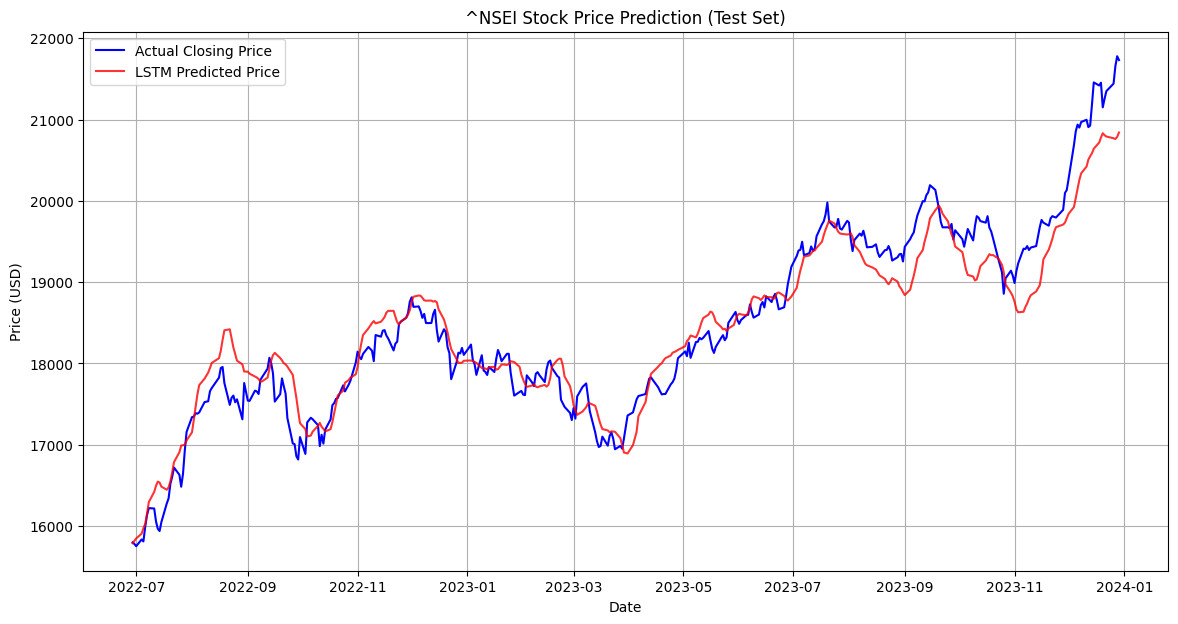

In [11]:
# ---------------------------------------------------------
# 5. EVALUATION & VISUALIZATION
# ---------------------------------------------------------
model.eval()
predictions = []
actuals = []

# Inference
with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)
        preds = model(batch_X)
        
        # Move back to CPU and convert to numpy
        predictions.extend(preds.cpu().numpy())
        actuals.extend(batch_y.numpy())

predictions = np.array(predictions)
actuals = np.array(actuals)

# Inverse transform to get real dollar values
# Our target_scaler expects a 2D array, which predictions and actuals already are: shape (N, 1)
predictions_real = target_scaler.inverse_transform(predictions)
actuals_real = target_scaler.inverse_transform(actuals)

# Calculate Evaluation Metrics
rmse = np.sqrt(mean_squared_error(actuals_real, predictions_real))
mae = mean_absolute_error(actuals_real, predictions_real)

print(f"Test RMSE: ${rmse:.2f}")
print(f"Test MAE:  ${mae:.2f}")

# Extract corresponding dates for the test set plotting
# The test data starts at 'split_index', but remember the sequence lookback offsets our y-values by 'lookback_window'
test_dates = df.index[lookback_window + split_index:]

# Plot Actual vs Predicted
plt.figure(figsize=(14, 7))
plt.plot(test_dates, actuals_real, label='Actual Closing Price', color='blue')
plt.plot(test_dates, predictions_real, label='LSTM Predicted Price', color='red', alpha=0.8)
plt.title(f"{ticker} Stock Price Prediction (Test Set)")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)
plt.show()